# Getriebe-Analyse Task 2
In diesem Notebook werden die Signaldaten aus Task 2 geladen und analysiert. Die Metadaten werden aus den Dateinamen extrahiert, um eine eindeutige Zuordnung der Signale zu Probe (spec), Position (pos) und Messreihen (mID/rID) zu ermöglichen.

In [66]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from dataframe_manager import DataFrameManager

# Pfad zum Datenordner in Task 2
data_path = '../data'

# Initialisierung des Managers und Laden der Signale
manager = DataFrameManager(data_dir=data_path)
manager.load_signals()

# Dataframe abrufen
df = manager.get_dataframe()
print(f"Erfolgreich {len(df)} Signale geladen.")
df.head()

Erfolgreich 440 Signale geladen.


,fn,sig,fs,spec,pos,mID,time,rID,sID
0,Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch1...,"[0.00048828125, 0.00244140625, 0.0029296875, 0...",1041666,Z01,Pos00,0000,1307031427,00000,Ch1
1,Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch2...,"[0.001953125, 0.0, 0.00146484375, 0.001953125,...",1041666,Z01,Pos00,0000,1307031427,00000,Ch2
2,Z01_Pos00_RC2_75k_0000_1307031427_00001_14_Ch1...,"[0.00146484375, 0.0, 0.00048828125, 0.00195312...",1041666,Z01,Pos00,0000,1307031427,00001,Ch1
3,Z01_Pos00_RC2_75k_0000_1307031427_00001_14_Ch2...,"[-0.00048828125, 0.0009765625, 0.0, -0.0009765...",1041666,Z01,Pos00,0000,1307031427,00001,Ch2
4,Z01_Pos00_RC2_75k_0001_1312091511_00000_14_Ch1...,"[0.00048828125, 0.00146484375, 0.00048828125, ...",1041666,Z01,Pos00,0001,1312091511,00000,Ch1


### Zelle 2: Feature-Extraktion und PCA
In dieser Zelle werden physikalische und psychoakustische Merkmale extrahiert, um den Zustand der Zahnräder statistisch beschreibbar zu machen.

#### 1. Spektrale Merkmale (Frequenzbereich)
*   **MFCCs (13 Koeffizienten):** Bilden die Spektraleinhüllende auf der Mel-Skala ab (ähnlich dem menschlichen Gehör).
*   **Spectral Centroid (Schwerpunkt):** Gibt an, bei welcher Frequenz der "Masseschwerpunkt" des Spektrums liegt. Ein Maß für die "Helligkeit" des Klangs.
    *   *Formel:* $f_c = \frac{\sum f \cdot P(f)}{\sum P(f)}$
*   **Spectral Bandwidth (Bandbreite):** Beschreibt die Spreizung des Spektrums um den Schwerpunkt.
*   **Spectral Roll-off:** Die Frequenz, unter der ein bestimmter Prozentsatz (meist 85%) der Spektralenergie liegt.
*   **Spectral Contrast:** Misst den Unterschied zwischen Spitzen und Tälern im Spektrum.
*   **Chroma Features (STFT/CENS):** Projizieren das gesamte Spektrum auf 12 Halbtonklassen.

#### 2. Zeitbereichs-Merkmale
*   **Zero Crossing Rate (ZCR):** Die Rate, mit der das Signal die Nulllinie kreuzt. Ein Maß für die Frequenz und Impulsivität (Rauschen).
    *   *Formel:* $ZCR = \frac{1}{2N} \sum_{n=1}^{N-1} |sign(x[n]) - sign(x[n-1])|$
*   **Frame Energy (RMS):** Der quadratische Mittelwert der Amplitude.
    *   *Formel:* $x_{rms} = \sqrt{\frac{1}{N} \sum x_i^2}$

#### 3. Dynamische Merkmale
*   **Delta-Features:** Die erste zeitliche Ableitung der MFCCs.

#### 4. PCA (Hauptkomponentenanalyse)
Die PCA reduziert diesen hochdimensionalen Merkmalsraum auf **zwei Komponenten (PC1 & PC2)**. Zuvor werden alle Merkmale **standardisiert** (Mittelwert 0, Varianz 1).

In [67]:
import librosa
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Globale Variable initialisieren, um NameError in Folgezellen zu vermeiden
pca_var_ratio = [0.0, 0.0]

def extract_features_comprehensive(df):
    all_features = []
    n_fft, hop_length, fmax = 4096, 1024, 200000
    
    print("Extrahiere Merkmale für 440 Signale...")
    for i, row in df.iterrows():
        sig, fs = row['sig'], row['fs']
        try:
            # Spektral
            mfcc = librosa.feature.mfcc(y=sig, sr=fs, n_mfcc=13, n_fft=n_fft, hop_length=hop_length, fmax=fmax)
            centroid = librosa.feature.spectral_centroid(y=sig, sr=fs, n_fft=n_fft, hop_length=hop_length)
            bandwidth = librosa.feature.spectral_bandwidth(y=sig, sr=fs, n_fft=n_fft, hop_length=hop_length)
            rolloff = librosa.feature.spectral_rolloff(y=sig, sr=fs, n_fft=n_fft, hop_length=hop_length)
            contrast = librosa.feature.spectral_contrast(y=sig, sr=fs, n_fft=n_fft, hop_length=hop_length, fmin=200)
            chroma_stft = librosa.feature.chroma_stft(y=sig, sr=fs, n_fft=n_fft, hop_length=hop_length)
            chroma_cens = librosa.feature.chroma_cens(y=sig, sr=fs, hop_length=hop_length)
            
            # Zeit & Dynamik
            zcr = librosa.feature.zero_crossing_rate(sig, frame_length=n_fft, hop_length=hop_length)
            energy = librosa.feature.rms(y=sig, frame_length=n_fft, hop_length=hop_length)
            delta_mfcc = librosa.feature.delta(mfcc)
            
            vector = np.hstack([
                np.mean(mfcc, axis=1), np.mean(centroid), np.mean(bandwidth), 
                np.mean(rolloff), np.mean(contrast, axis=1), 
                np.mean(chroma_stft, axis=1), np.mean(chroma_cens, axis=1), 
                np.mean(zcr), np.mean(energy), np.mean(delta_mfcc, axis=1)
            ])
            all_features.append(vector)
        except Exception: continue
    return np.array(all_features)

features_matrix = extract_features_comprehensive(df)
X = pd.DataFrame(features_matrix).apply(pd.to_numeric, errors='coerce').fillna(0)
X = X.loc[:, (X.std() > 1e-10)]

if X.shape[1] > 0:
    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2)
    results = pca.fit_transform(X_scaled)
    df['PC1'], df['PC2'] = results[:, 0], results[:, 1]
    pca_var_ratio = pca.explained_variance_ratio_ * 100
    print(f"PCA abgeschlossen. Merkmale: {X.shape[1]}. Varianz: {np.sum(pca.explained_variance_ratio_):.2%}")
else:
    print("Fehler: Keine variablen Merkmale gefunden.")
df[['spec', 'pos', 'mID', 'PC1', 'PC2']].head()

Extrahiere Merkmale für 440 Signale...
PCA abgeschlossen. Merkmale: 55. Varianz: 37.43%


,spec,pos,mID,PC1,PC2
0,Z01,Pos00,0000,1.962044,-1.035491
1,Z01,Pos00,0000,-3.593912,0.130516
2,Z01,Pos00,0000,0.792450,-1.261707
3,Z01,Pos00,0000,-5.279511,-0.057707
4,Z01,Pos00,0001,1.828636,-2.683074


### Zelle 3: Stabilitätsanalyse (rID & mID Vergleich)
Visualisierung der Reproduzierbarkeit und zeitlichen Stabilität (vertikales Layout).

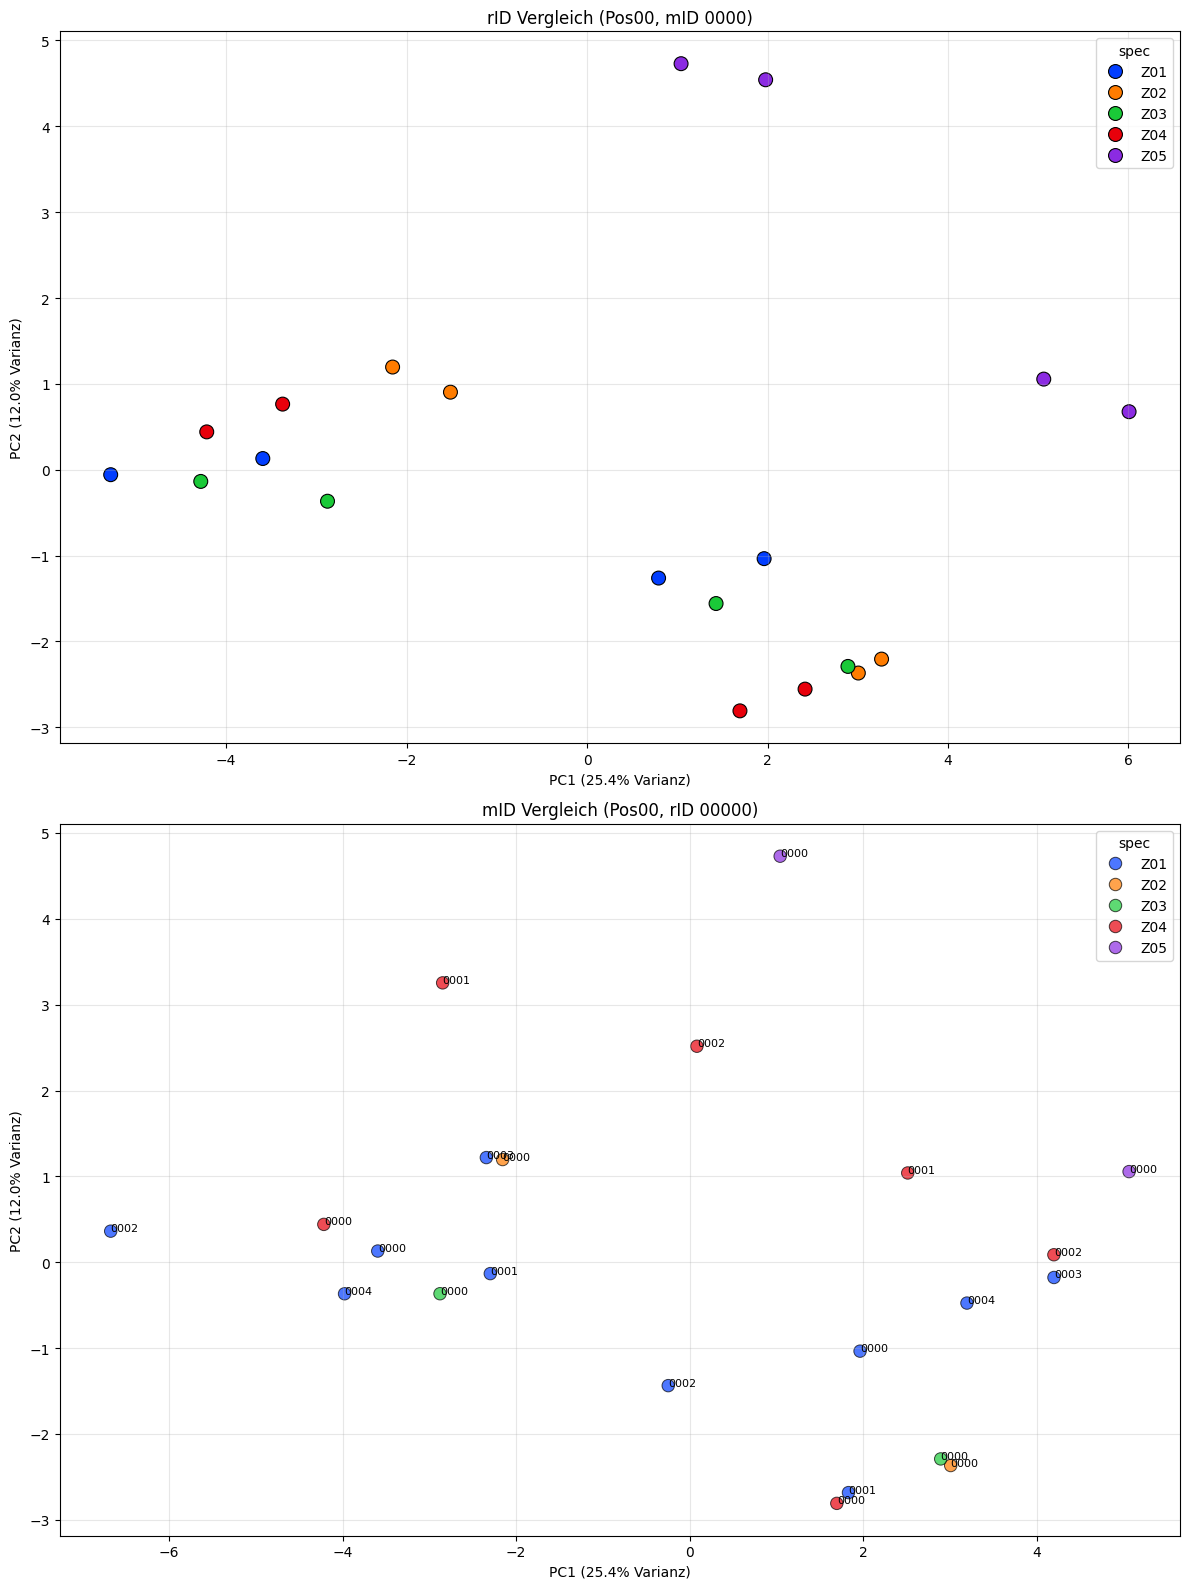

In [68]:
import seaborn as sns
v1, v2 = pca_var_ratio[0], pca_var_ratio[1]
plt.figure(figsize=(12, 16))

# --- Plot 1: rID Vergleich ---
plt.subplot(2, 1, 1)
df_rid = df[(df['pos'] == 'Pos00') & (df['mID'] == '0000')]
sns.scatterplot(data=df_rid, x='PC1', y='PC2', hue='spec', s=100, palette='bright', edgecolors='k')
plt.title("rID Vergleich (Pos00, mID 0000)")
plt.xlabel(f"PC1 ({v1:.1f}% Varianz)"); plt.ylabel(f"PC2 ({v2:.1f}% Varianz)")
plt.grid(True, alpha=0.3)

# --- Plot 2: mID Vergleich ---
plt.subplot(2, 1, 2)
df_mid = df[(df['pos'] == 'Pos00') & (df['rID'] == '00000')]
sns.scatterplot(data=df_mid, x='PC1', y='PC2', hue='spec', s=80, palette='bright', alpha=0.7, edgecolors='k')
for i in range(df_mid.shape[0]):
    plt.text(df_mid.PC1.iloc[i], df_mid.PC2.iloc[i], str(df_mid.mID.iloc[i]), fontsize=8)
plt.title("mID Vergleich (Pos00, rID 00000)")
plt.xlabel(f"PC1 ({v1:.1f}% Varianz)"); plt.ylabel(f"PC2 ({v2:.1f}% Varianz)")
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Zelle 4: Detaillierter Vergleich (Kanäle & Positionen)
Kanaltrennung (Ch1 vs. Ch2) über verschiedene Konfigurationen (6 Plots).

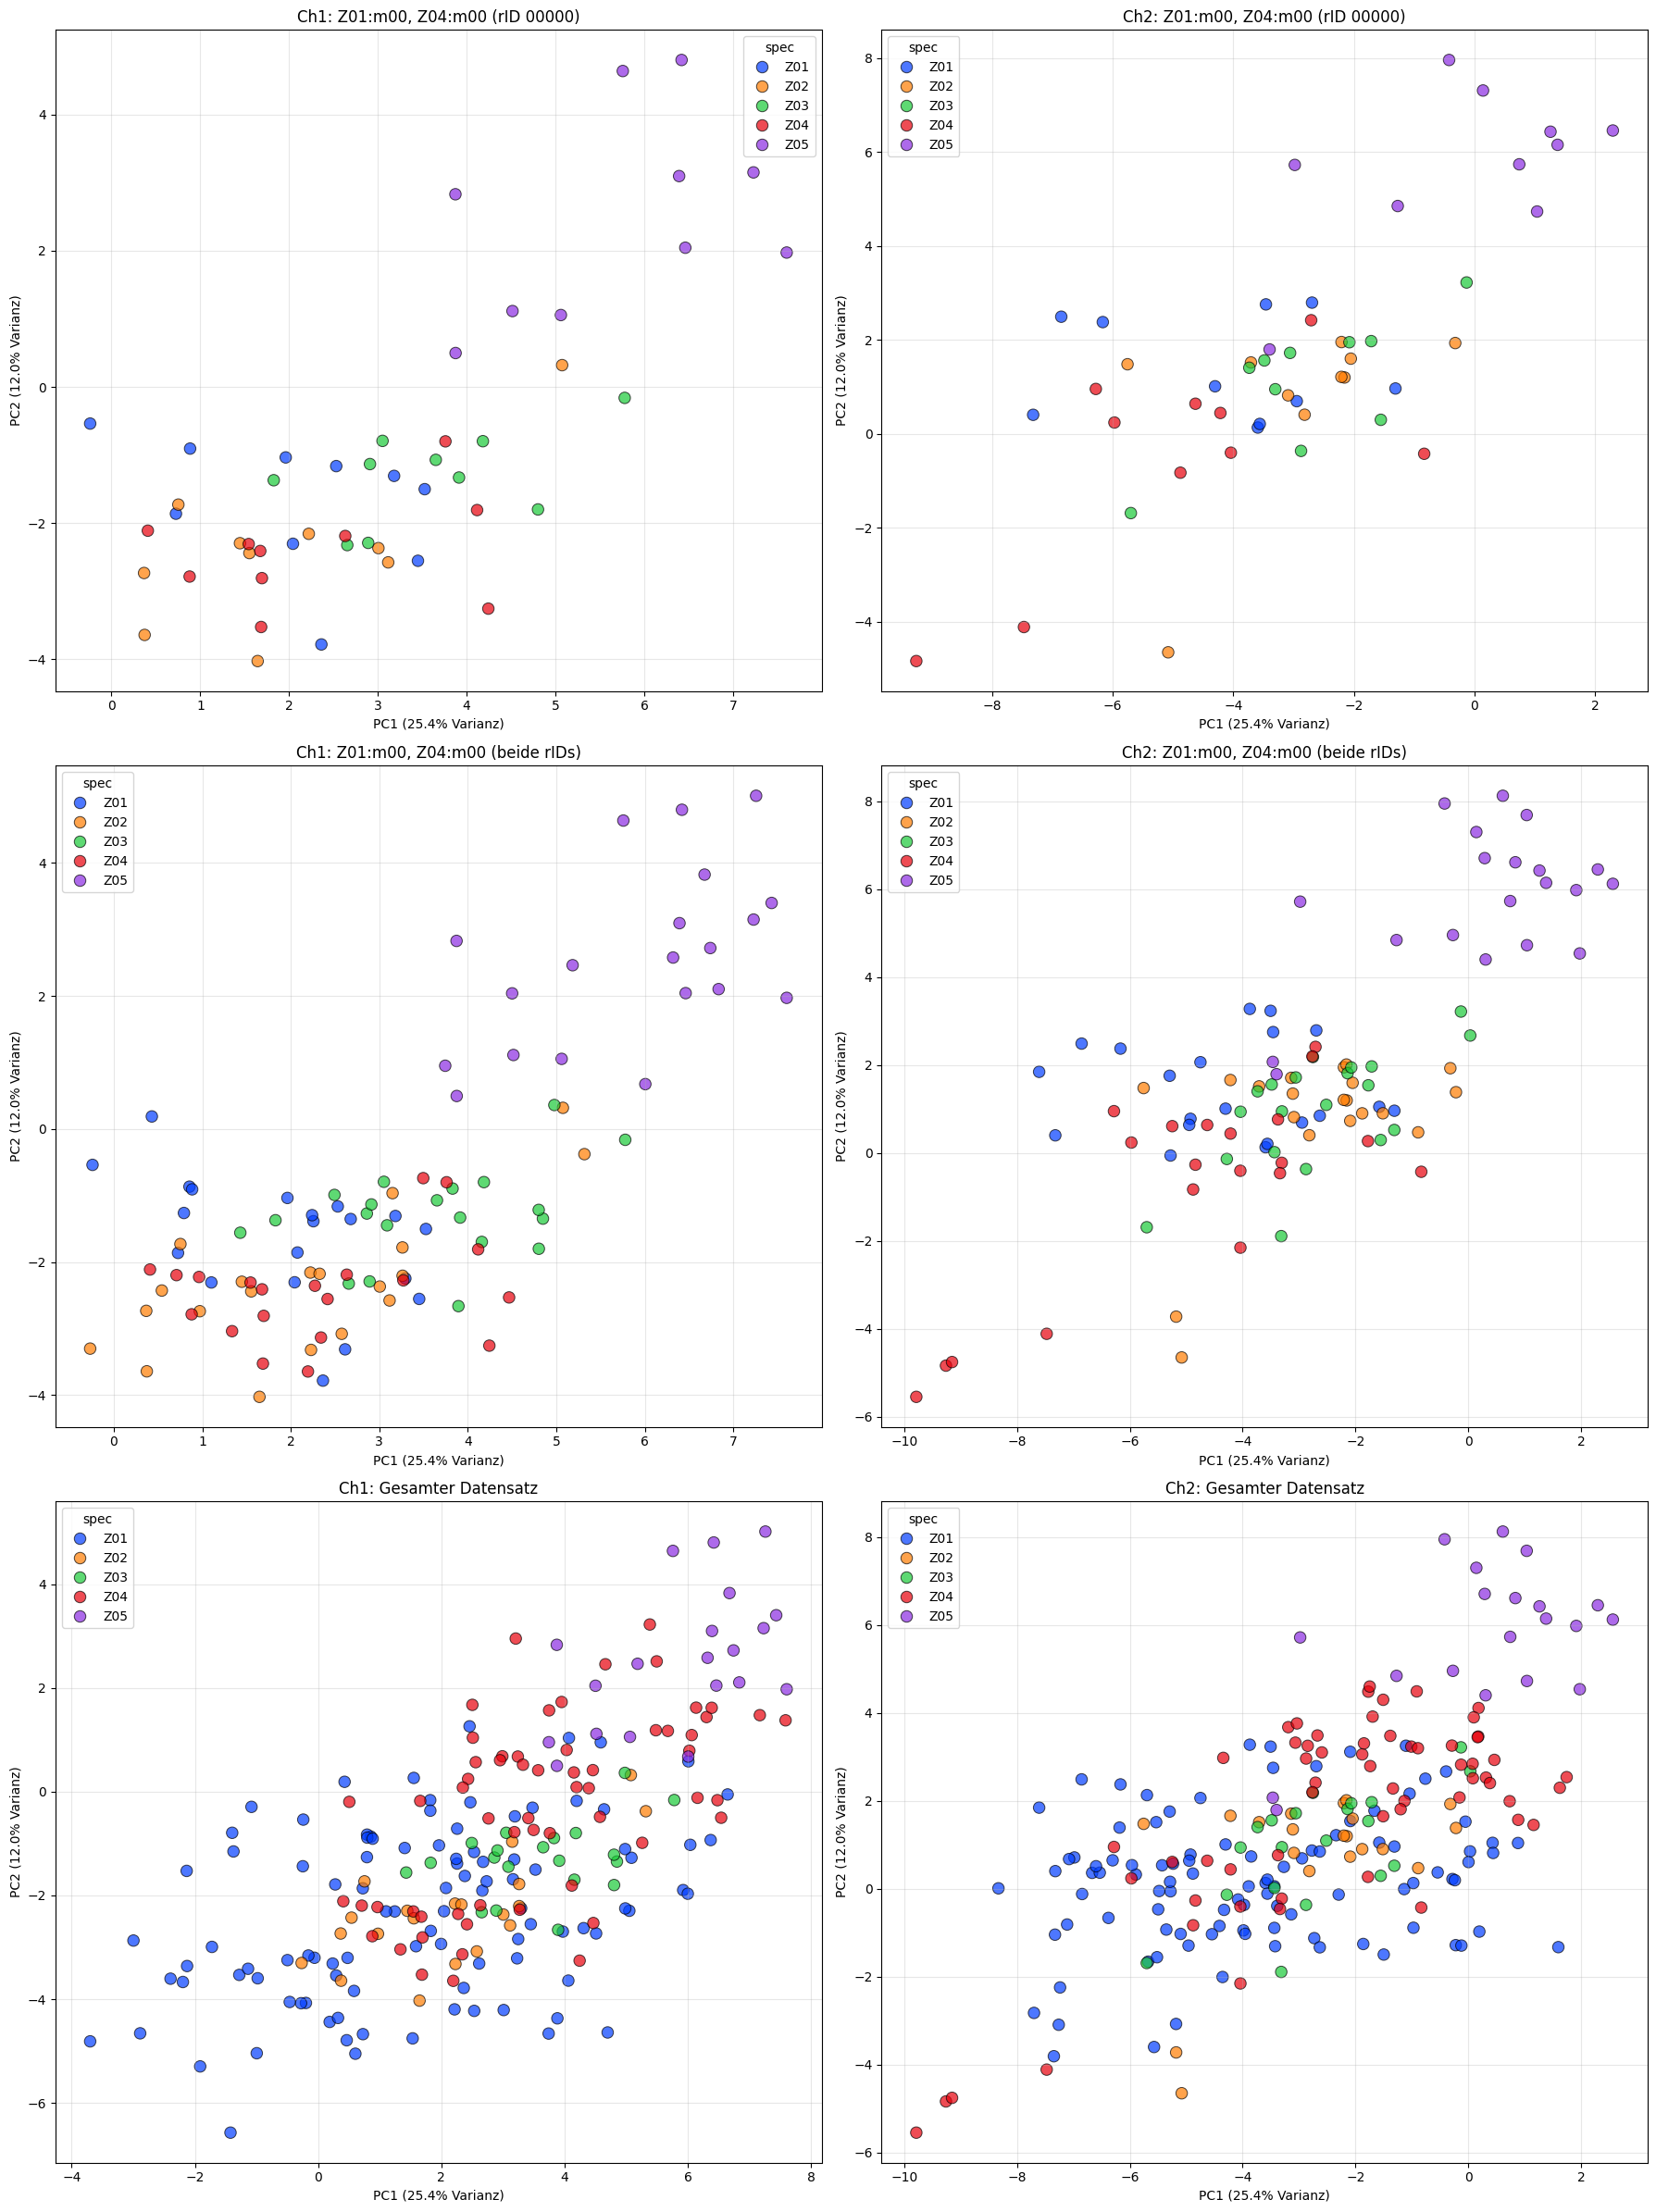

In [71]:
v1, v2 = pca_var_ratio[0], pca_var_ratio[1]
plt.figure(figsize=(18, 24))
m_r0 = (df['rID'] == '00000') & (((df['spec'] == 'Z01') & (df['mID'] == '0000')) | ((df['spec'] == 'Z04') & (df['mID'] == '0000')) | (df['spec'].isin(['Z02', 'Z03', 'Z05']) & (df['mID'] == '0000')))
m_br = (((df['spec'] == 'Z01') & (df['mID'] == '0000')) | ((df['spec'] == 'Z04') & (df['mID'] == '0000')) | (df['spec'].isin(['Z02', 'Z03', 'Z05']) & (df['mID'] == '0000')))
configs = [("Z01:m00, Z04:m00 (rID 00000)", m_r0), ("Z01:m00, Z04:m00 (beide rIDs)", m_br), ("Gesamter Datensatz", slice(None))]

idx = 1
for title, mask in configs:
    for chan in ['Ch1', 'Ch2']:
        plt.subplot(3, 2, idx)
        df_s = df[mask] if isinstance(mask, pd.Series) else df
        df_sc = df_s[df_s['sID'] == chan]
        sns.scatterplot(data=df_sc, x='PC1', y='PC2', hue='spec', s=80, palette='bright', edgecolors='k', alpha=0.7)
        plt.title(f"{chan}: {title}")
        plt.xlabel(f"PC1 ({v1:.1f}% Varianz)"); plt.ylabel(f"PC2 ({v2:.1f}% Varianz)")
        plt.grid(True, alpha=0.3); idx += 1
plt.tight_layout(); plt.show()